# Pravin Suranthiran –  Model Selection

For the purpose of predicting PM2.5 concentrations in the dataset, various models are tested and compared.
This is done in two cases: 
- nowcasting (using highly-correlated features such as SO2, NO2, CO, O3 and weather data)
- forecasting (only using weather data). 
- PM10 correlates too closely with PM2.5 and is excluded from both models.

In [43]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, f1_score, confusion_matrix,
)
import xgboost as xgb

RANDOM_STATE = 42

In [44]:
POLLUTANT_FEATURES = ["SO2", "NO2", "CO", "O3"]
WEATHER_FEATURES = ["TEMP", "PRES", "DEWP", "RAIN", "WSPM"]
TIME_FEATURES = ["hour_sin", "hour_cos", "month_sin", "month_cos"]

FEATURE_SETS = {
    "Pollutants + weather (nowcast)": POLLUTANT_FEATURES + WEATHER_FEATURES + TIME_FEATURES,
    "Weather only (forecast)": WEATHER_FEATURES + TIME_FEATURES,
}


In [45]:
base_dir = "../datasets/raw"
csv_files = [f for f in os.listdir(base_dir) if f.endswith(".csv") and f.startswith("PRSA_Data")]

dfs = []
for f in csv_files:
    tmp = pd.read_csv(os.path.join(base_dir, f))
    station = f.replace("PRSA_Data_", "").replace("_20130301-20170228.csv", "")
    tmp["station"] = station
    dfs.append(tmp)
df = pd.concat(dfs, ignore_index=True)

df_clean = df.drop(columns=["PM10", "wd"]).copy()
df_clean = df_clean.dropna()
print(f"df shape: {df.shape}")
print(f"df_clean shape: {df_clean.shape}")

df shape: (420768, 18)
df_clean shape: (383767, 16)


In [46]:
STATIONS = df_clean["station"].unique()

SCOPES = {"All stations": None}
SCOPES.update({f"{station} only": station for station in STATIONS})

print(f"{'Station':<20} | {'Data Points':<12}")
print("-" * 35)
for station in STATIONS:
    count = len(df_clean[df_clean["station"] == station])
    print(f"{station:<20} | {count:<12,}")

Station              | Data Points 
-----------------------------------
Aotizhongxin         | 31,884      
Changping            | 32,786      
Dingling             | 31,420      
Dongsi               | 30,418      
Guanyuan             | 32,339      
Gucheng              | 32,632      
Huairou              | 31,969      
Nongzhanguan         | 33,191      
Shunyi               | 30,606      
Tiantan              | 32,923      
Wanliu               | 30,753      
Wanshouxigong        | 32,846      


In [ ]:
# Converted into cyclical units
df_model = df_clean.copy()
df_model["datetime"] = pd.to_datetime(df_model[["year", "month", "day", "hour"]])
df_model = df_model.sort_values(["station", "datetime"]).reset_index(drop=True)

# Edges for AQI are arbitrary, so some data leakage here is considered acceptable.
_, QUINTILE_EDGES = pd.qcut(df_model["PM2.5"], q=5, retbins=True, duplicates="drop")
QUINTILE_EDGES[0], QUINTILE_EDGES[-1] = -np.inf, np.inf
_, BINARY_EDGES = pd.qcut(df_model["PM2.5"], q=2, retbins=True, duplicates="drop")
BINARY_EDGES [0], BINARY_EDGES [-1] = -np.inf, np.inf

df_model["hour_sin"] = np.sin(2 * np.pi * df_model["hour"] / 24)
df_model["hour_cos"] = np.cos(2 * np.pi * df_model["hour"] / 24)
df_model["month_sin"] = np.sin(2 * np.pi * df_model["month"] / 12)
df_model["month_cos"] = np.cos(2 * np.pi * df_model["month"] / 12)

SCOPES = {"All stations": None}
SCOPES.update({f"{station} only": station for station in STATIONS})

df_model = pd.get_dummies(df_model, columns=["station"], drop_first=False, dtype=int)

print(f"df_model shape: {df_model.shape}")
print(df_model.columns)
print(f"date range: {df_model['datetime'].min()} to {df_model['datetime'].max()}")

Quintile Edges: [-inf  16.  39.  73. 128.  inf]
Binary Edges: [-inf  55.  inf]
df_model shape: (383767, 32)
Index(['No', 'year', 'month', 'day', 'hour', 'PM2.5', 'SO2', 'NO2', 'CO', 'O3',
       'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM', 'datetime', 'hour_sin',
       'hour_cos', 'month_sin', 'month_cos', 'station_Aotizhongxin',
       'station_Changping', 'station_Dingling', 'station_Dongsi',
       'station_Guanyuan', 'station_Gucheng', 'station_Huairou',
       'station_Nongzhanguan', 'station_Shunyi', 'station_Tiantan',
       'station_Wanliu', 'station_Wanshouxigong'],
      dtype='str')
date range: 2013-03-01 00:00:00 to 2017-02-28 23:00:00


In [48]:
def prepare_dataset(df, feature_cols, station=None, train_frac=0.8):
    # station=None pools every station together, or takes a station name to restrict model to that subset
    station_cols = [c for c in df.columns if c.startswith("station_")]
    if station is None:
        data = df
        model_features = feature_cols + station_cols
    else:
        data = df[df[f"station_{station}"] == 1].drop(columns=station_cols)
        model_features = feature_cols

    data = data.sort_values("datetime").reset_index(drop=True)
    cutoff = data["datetime"].quantile(train_frac)
    train_mask = data["datetime"] < cutoff

    X_train = data.loc[train_mask, model_features].reset_index(drop=True)
    X_test = data.loc[~train_mask, model_features].reset_index(drop=True)
    y_train = data.loc[train_mask, "PM2.5"].reset_index(drop=True)
    y_test = data.loc[~train_mask, "PM2.5"].reset_index(drop=True)

    # quintile PM2.5 split for classifiers
    labels = [f"Q{i + 1}" for i in range(len(QUINTILE_EDGES) - 1)]
    y_train_cls = pd.cut(y_train, bins=QUINTILE_EDGES, labels=labels)
    y_test_cls = pd.cut(y_test, bins=QUINTILE_EDGES, labels=labels)

    # binary PM2.5 split for binary classifiers
    labels = [f"H{i + 1}" for i in range(len(BINARY_EDGES) - 1)]
    y_train_binary = pd.cut(y_train, bins=BINARY_EDGES, labels=labels)
    y_test_binary = pd.cut(y_test, bins=BINARY_EDGES, labels=labels)

    return {
        "X_train": X_train, "X_test": X_test,
        "y_train": y_train, "y_test": y_test,
        "y_train_cls": y_train_cls, "y_test_cls": y_test_cls,
        "y_train_binary": y_train_binary, "y_test_binary": y_test_binary,
        "n_train": int(train_mask.sum()), "n_test": int((~train_mask).sum()),
        "test_start": data.loc[~train_mask, "datetime"].min(),
        "test_end": data.loc[~train_mask, "datetime"].max(),
    }


**OLS (Linear Regression)**
- Assumes a linear relationship between features and PM2.5
- Assumes independent observations
- Assumes no multicollinearity
- Uses scaling

**Random Forest**
- Assumes independent observations
- Allows multicollinearity
- Used for both regression and classification tasks

**XGBoost**
- Allows multicollinearity
- Can technically handle missing data but for the sake of model comparison, the same train and test are used for all
- Used for both regression and classification tasks

**Logistic Regression**
- Assumes indepenent observations
- Assumes no multicollinearity
- Uses scaling

**Naive Bayes**
- Assumes conditional independence of features
- Uses scaling

In [49]:
def run_regressors(split):
    models = {
        "OLS": Pipeline([
                ("scale", StandardScaler()),
                ("model", LinearRegression()),
            ]),
        #"Random Forest": RandomForestRegressor(n_estimators=150, n_jobs=-1, random_state=RANDOM_STATE),
        "XGBoost": xgb.XGBRegressor(
            n_estimators=300, learning_rate=0.05, max_depth=4,
            subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_STATE, n_jobs=-1,
        ),
    }
    
    station_cols = [col for col in split["X_test"].columns if col.startswith("station_")]

    rows, fitted = {}, {}
    for name, model in models.items():
        model.fit(split["X_train"], split["y_train"])
        preds = model.predict(split["X_test"])
        rows[name] = {
            "RMSE": np.sqrt(mean_squared_error(split["y_test"], preds)),
            "MAE": mean_absolute_error(split["y_test"], preds),
            "R2": r2_score(split["y_test"], preds),
            "station": {}
        }
        for col in station_cols:
            if col in split["X_test"].columns and (split["X_test"][col] == 1).any():
                mask = split["X_test"][col] == 1
                station_name = col.replace("station_", "")
                
                rows[name]["station"][station_name] = {
                        "RMSE": np.sqrt(mean_squared_error(split["y_test"][mask], preds[mask])),
                        "MAE": mean_absolute_error(split["y_test"][mask], preds[mask]),
                        "R2": r2_score(split["y_test"][mask], preds[mask]),
                    }
        fitted[name] = model
    return pd.DataFrame(rows).T.sort_values("RMSE"), fitted

In [50]:
def run_classifiers(split):
    label_encoder = LabelEncoder()
    y_train_enc = label_encoder.fit_transform(split["y_train_cls"])
    y_test_enc = label_encoder.transform(split["y_test_cls"])

    models = {
        "Logistic Regression": Pipeline([
                ("scale", StandardScaler()),
                ("model", LogisticRegression(max_iter=1000)),
            ]),
        #"Naive Bayes":  Pipeline([
        #        ("scale", StandardScaler()),
        #        ("model", GaussianNB()),
        #    ]),
        #"Random Forest": RandomForestClassifier(n_estimators=150, n_jobs=-1, max_depth=4, random_state=RANDOM_STATE),
        "XGBoost": xgb.XGBClassifier(
            n_estimators=300, learning_rate=0.05, max_depth=4,
            subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_STATE,
            n_jobs=-1, eval_metric="mlogloss",
        ),
    }

    station_cols = [col for col in split["X_test"].columns if col.startswith("station_")]

    rows, fitted = {}, {}
    for name, model in models.items():
        model.fit(split["X_train"], y_train_enc)
        preds = model.predict(split["X_test"])
        rows[name] = {
            "Accuracy": accuracy_score(y_test_enc, preds),
            "F1_weighted": f1_score(y_test_enc, preds, average="weighted"),
            "station": {}
        }
        for col in station_cols:
            if col in split["X_test"].columns and (split["X_test"][col] == 1).any():
                mask = split["X_test"][col] == 1
                station_name = col.replace("station_", "")
                
                rows[name]["station"][station_name] = {
                        "Accuracy": accuracy_score(y_test_enc[mask], preds[mask]),
                        "F1_weighted": f1_score(y_test_enc[mask], preds[mask], average="weighted"),
                    }
        fitted[name] = model
    return pd.DataFrame(rows).T.sort_values("Accuracy", ascending=False), fitted, label_encoder


In [51]:
def run_binary_classifiers(split):
    label_encoder = LabelEncoder()
    y_train_enc = label_encoder.fit_transform(split["y_train_binary"])
    y_test_enc = label_encoder.transform(split["y_test_binary"])

    models = {
        "Logistic Regression": Pipeline([
                ("scale", StandardScaler()),
                ("model", LogisticRegression(max_iter=1000)),
            ]),
        #"Naive Bayes":  Pipeline([
        #        ("scale", StandardScaler()),
        #        ("model", GaussianNB()),
        #       ]),
        #"Random Forest": RandomForestClassifier(n_estimators=150, max_depth=4, n_jobs=-1, random_state=RANDOM_STATE),
        "XGBoost": xgb.XGBClassifier(
            n_estimators=300, learning_rate=0.05, max_depth=4,
            subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_STATE,
            n_jobs=-1, eval_metric="mlogloss",
        )
    }

    station_cols = [col for col in split["X_test"].columns if col.startswith("station_")]

    rows, fitted = {}, {}
    for name, model in models.items():
        model.fit(split["X_train"], y_train_enc)
        preds = model.predict(split["X_test"])
        rows[name] = {
            "Accuracy": accuracy_score(y_test_enc, preds),
            "F1_weighted": f1_score(y_test_enc, preds, average="weighted"),
            "station": {}
        }
        for col in station_cols:
            if col in split["X_test"].columns and (split["X_test"][col] == 1).any():
                mask = split["X_test"][col] == 1
                station_name = col.replace("station_", "")
                
                rows[name]["station"][station_name]={
                        "Accuracy": accuracy_score(y_test_enc[mask], preds[mask]),
                        "F1_weighted": f1_score(y_test_enc[mask], preds[mask], average="weighted"),
                    }
        fitted[name] = model
    return pd.DataFrame(rows).T.sort_values("Accuracy", ascending=False), fitted, label_encoder


In [52]:
regression_results = {}
classification_results = {}
binary_results = {}
fitted_models = {}
splits = {}

for feature, feature_cols in FEATURE_SETS.items():
    for scope, station in SCOPES.items():
        key = (feature, scope)
        split = prepare_dataset(df_model, feature_cols, station=station)
        reg_table, reg_models = run_regressors(split)
        clf_table, clf_models, label_encoder = run_classifiers(split)
        binary_table, binary_models, binary_label_encoder = run_binary_classifiers(split)
        splits[key] = split

        regression_results[key] = reg_table
        classification_results[key] = clf_table
        binary_results[key] = binary_table

        reg_table = reg_table.drop(columns=['station'], errors='ignore')
        clf_table = clf_table.drop(columns=['station'], errors='ignore')
        binary_table = binary_table.drop(columns=['station'], errors='ignore')

        fitted_models[key] = {
            "regression": reg_models,
            "quintile classification": clf_models,
            "binary classification": binary_models,
            "label_encoder": label_encoder,
            "binary_label_encoder": binary_label_encoder
        }

        print(f"\n=== {feature} | {scope} ===")
        print(f"train rows: {split['n_train']:,} | test rows: {split['n_test']:,} "
              f"(test period {split['test_start'].date()} to {split['test_end'].date()})")
        print("\nRegression:")
        print(reg_table.round(3).to_string())
        print("\nClassification (PM2.5 quintile):")
        print(clf_table.round(3).to_string())
        print("\nClassification (PM2.5 binary):")
        print(binary_table.round(3).to_string())


=== Pollutants + weather (nowcast) | All stations ===
train rows: 307,009 | test rows: 76,758 (test period 2016-05-21 to 2017-02-28)

Regression:
              RMSE        MAE        R2
XGBoost  38.231672  23.323254  0.792767
OLS      40.604856  27.741679  0.766241

Classification (PM2.5 quintile):
                     Accuracy F1_weighted
XGBoost               0.62473    0.621803
Logistic Regression  0.612549    0.613329

Classification (PM2.5 binary):
                     Accuracy F1_weighted
XGBoost               0.87626    0.876255
Logistic Regression  0.866242    0.866124

=== Pollutants + weather (nowcast) | Aotizhongxin only ===
train rows: 25,507 | test rows: 6,377 (test period 2016-05-24 to 2017-02-28)

Regression:
              RMSE        MAE        R2
XGBoost  37.905636  23.350616  0.805153
OLS      39.176122  26.434463  0.791872

Classification (PM2.5 quintile):
                     Accuracy F1_weighted
Logistic Regression  0.625216    0.628218
XGBoost              0.5976

In [53]:
def compare_scope_performance(feature, local_scope):
    station_name = SCOPES[local_scope]

    pooled = regression_results[(feature, "All stations")]
    local = regression_results[(feature, f"{station_name} only")]

    # Extract the pooled model's performance at this station
    pooled_local_r2s = pooled['station'].apply(lambda x: x[station_name]['R2'])
    
    pooled_best_model = pooled_local_r2s.idxmax()
    pooled_r2 = pooled_local_r2s.max()

    local_best_model = local["R2"].idxmax()
    local_r2 = local.loc[local_best_model, "R2"]                                         
    
    print(f"{feature}:")
    print(f"  Pooled (Local Eval) -> best R2 = {pooled_r2:.3f} ({pooled_best_model})")
    print(f"  {local_scope:<19} -> best R2 = {local_r2:.3f} ({local_best_model})\n")

# Call the function passing the raw station name
for feature in FEATURE_SETS:
    for station in STATIONS:
        compare_scope_performance(feature, f"{station} only")

Pollutants + weather (nowcast):
  Pooled (Local Eval) -> best R2 = 0.812 (XGBoost)
  Aotizhongxin only   -> best R2 = 0.805 (XGBoost)

Pollutants + weather (nowcast):
  Pooled (Local Eval) -> best R2 = 0.745 (OLS)
  Changping only      -> best R2 = 0.756 (OLS)

Pollutants + weather (nowcast):
  Pooled (Local Eval) -> best R2 = 0.826 (XGBoost)
  Dingling only       -> best R2 = 0.794 (XGBoost)

Pollutants + weather (nowcast):
  Pooled (Local Eval) -> best R2 = 0.782 (XGBoost)
  Dongsi only         -> best R2 = 0.800 (XGBoost)

Pollutants + weather (nowcast):
  Pooled (Local Eval) -> best R2 = 0.794 (XGBoost)
  Guanyuan only       -> best R2 = 0.792 (XGBoost)

Pollutants + weather (nowcast):
  Pooled (Local Eval) -> best R2 = 0.821 (XGBoost)
  Gucheng only        -> best R2 = 0.808 (XGBoost)

Pollutants + weather (nowcast):
  Pooled (Local Eval) -> best R2 = 0.800 (XGBoost)
  Huairou only        -> best R2 = 0.807 (XGBoost)

Pollutants + weather (nowcast):
  Pooled (Local Eval) -> best R

In [54]:
def plot_compare(results, metric, ylabel, title):
    fig, axes = plt.subplots(1, len(FEATURE_SETS), figsize=(6 * len(FEATURE_SETS), 4.5), sharey=True)
    scope_keys = list(SCOPES.keys())
    width = 0.2

    for ax, feature in zip(axes, FEATURE_SETS):
        models = results[(feature, scope_keys[0])].index.tolist()
        x = np.arange(len(models))
        for i, scope in enumerate(scope_keys[0:4]):
            values = results[(feature, scope)][metric].values
            ax.bar(x + i * width, values, width, label=scope)
        ax.set_xticks(x + width / 2)
        ax.set_xticklabels(models, rotation=30, ha="right")
        ax.set_title(feature, fontsize=11)
        ax.grid(axis="y", alpha=0.3)
        ax.axhline(0, color="black", lw=0.8)

    axes[0].set_ylabel(ylabel)
    axes[0].legend()
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

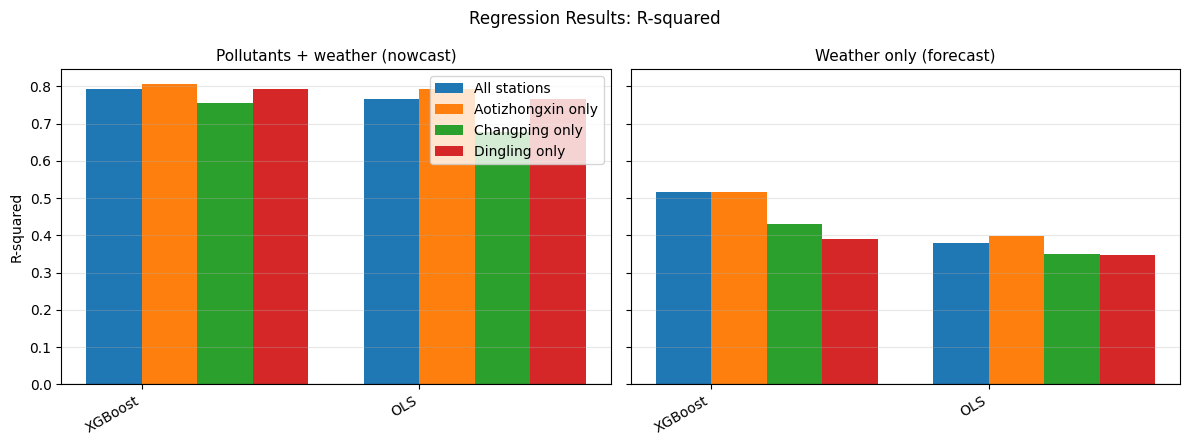

In [55]:
plot_compare(regression_results, "R2", "R-squared", "Regression Results: R-squared")

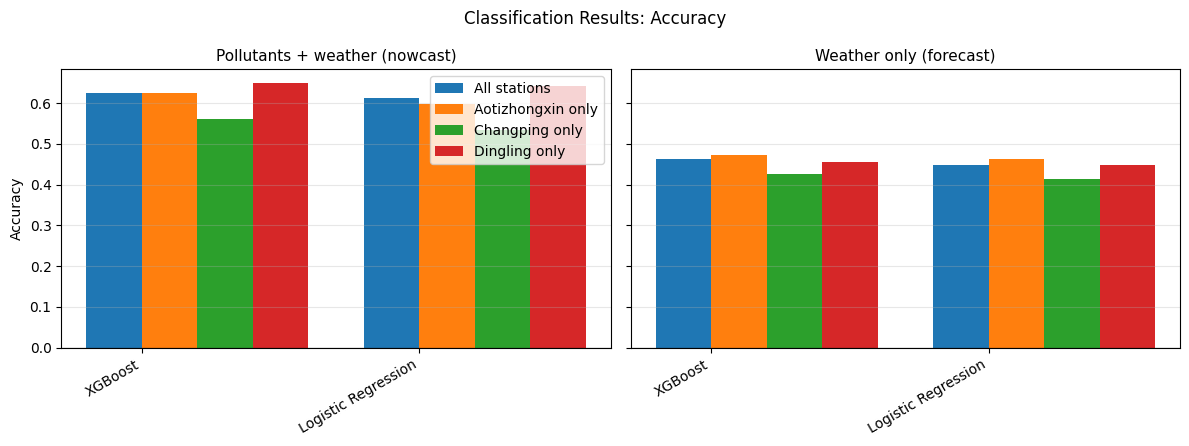

In [56]:
plot_compare(classification_results, "Accuracy", "Accuracy", "Classification Results: Accuracy")

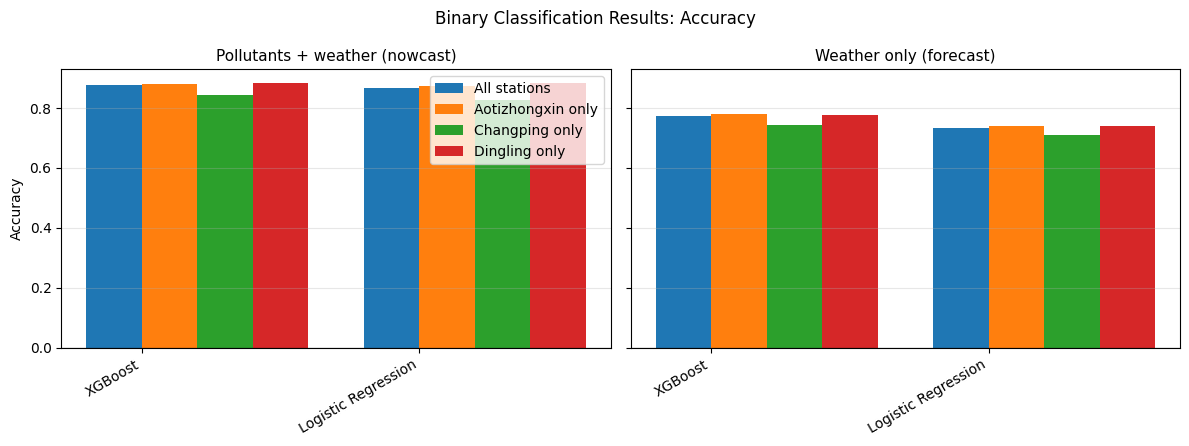

In [57]:
plot_compare(binary_results, "Accuracy", "Accuracy", "Binary Classification Results: Accuracy")

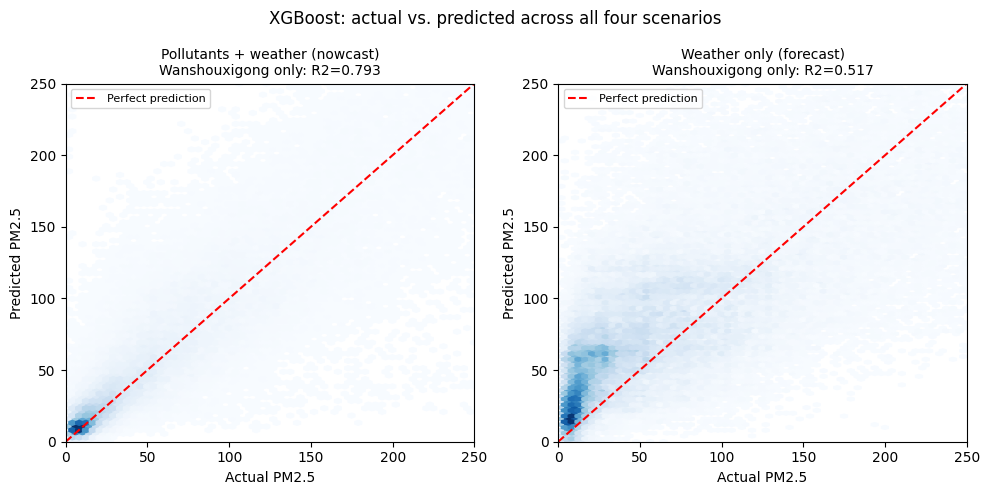

In [58]:
fig, axes = plt.subplots(1,2, figsize=(10, 5))

for ax, feature in zip(axes, FEATURE_SETS):
    split = splits[(feature, "All stations")]
    model = fitted_models[(feature, "All stations")]["regression"]["XGBoost"]
    preds = model.predict(split["X_test"])
    r2 = r2_score(split["y_test"], preds)

    hb = ax.hexbin(split["y_test"], preds, gridsize=200, cmap="Blues", mincnt=1)
    ax.plot([0, 250], [0, 250], "r--", lw=1.5, label="Perfect prediction")
    ax.set_xlim(0, 250)
    ax.set_ylim(0, 250)
    ax.set_xlabel("Actual PM2.5")
    ax.set_ylabel("Predicted PM2.5")
    ax.set_title(f"{feature}\n{scope}: R2={r2:.3f}", fontsize=10)
    ax.legend(fontsize=8)

fig.suptitle("XGBoost: actual vs. predicted across all four scenarios")
plt.tight_layout()
plt.show()

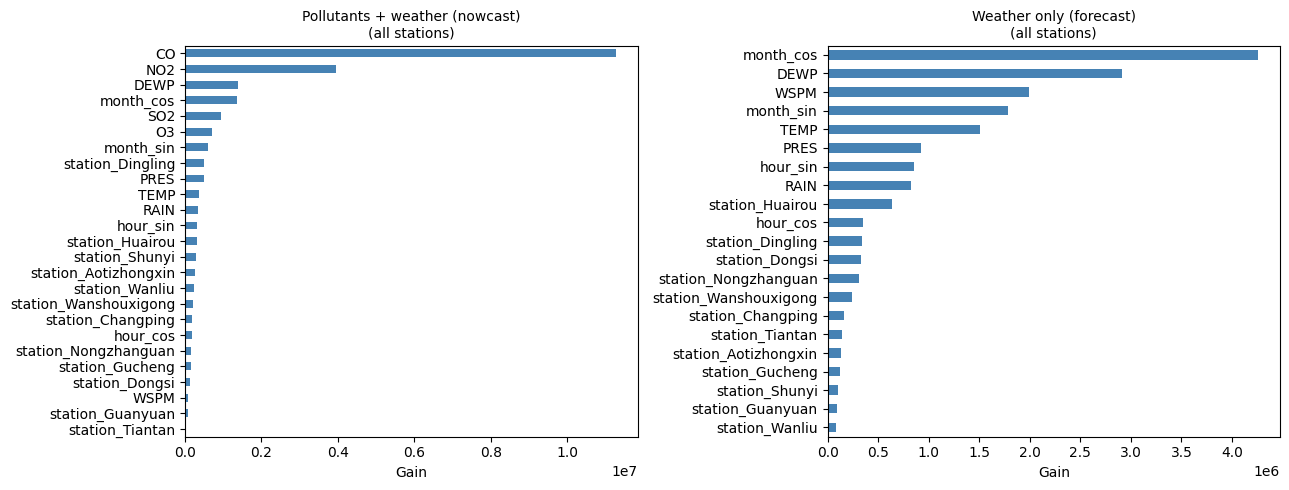

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, feature in zip(axes, FEATURE_SETS):
    split = splits[(feature, "All stations")]
    model = fitted_models[(feature, "All stations")]["regression"]["XGBoost"]
    gain_scores = model.get_booster().get_score(importance_type='gain')
    importances = pd.Series(gain_scores).reindex(split["X_train"].columns, fill_value=0).sort_values()

    importances.plot(kind="barh", ax=ax, color="steelblue")
    ax.set_xlabel("Gain")
    ax.set_title(f"{feature}\n(all stations)", fontsize=10)

plt.tight_layout()
plt.show()

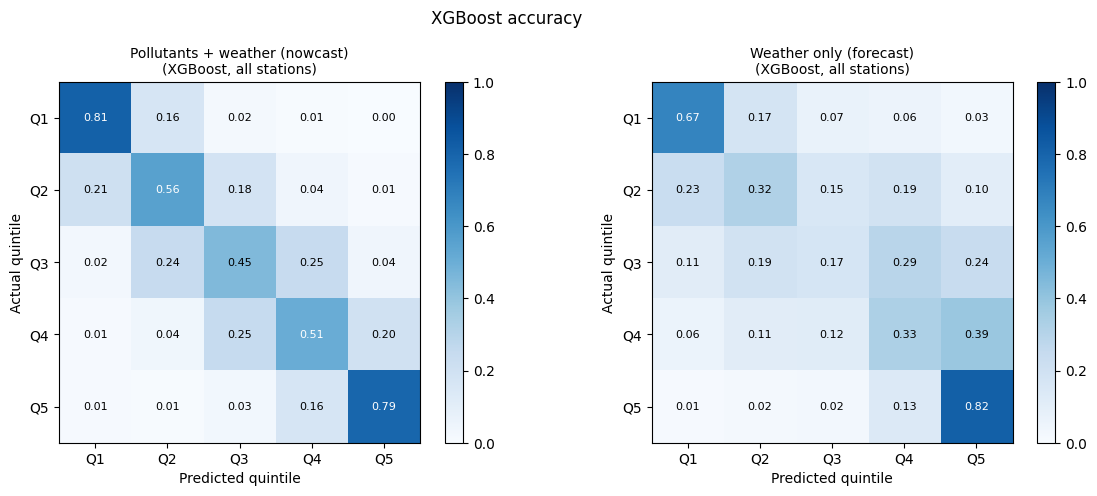

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, feature in zip(axes, FEATURE_SETS):
    key = (feature, "All stations")
    split = splits[key]
    model = fitted_models[key]["quintile classification"]["XGBoost"]
    label_encoder = fitted_models[key]["label_encoder"]

    y_test_enc = label_encoder.transform(split["y_test_cls"])
    preds = model.predict(split["X_test"])
    cm = confusion_matrix(y_test_enc, preds, normalize="true")

    im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(len(label_encoder.classes_)))
    ax.set_xticklabels(label_encoder.classes_)
    ax.set_yticks(range(len(label_encoder.classes_)))
    ax.set_yticklabels(label_encoder.classes_)
    ax.set_xlabel("Predicted quintile")
    ax.set_ylabel("Actual quintile")
    ax.set_title(f"{feature}\n(XGBoost, all stations)", fontsize=10)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, f"{cm[i, j]:.2f}", ha="center", va="center",
                     color="white" if cm[i, j] > 0.5 else "black", fontsize=8)
    plt.colorbar(im, ax=ax, fraction=0.046)

fig.suptitle("XGBoost accuracy")
plt.tight_layout()
plt.show()

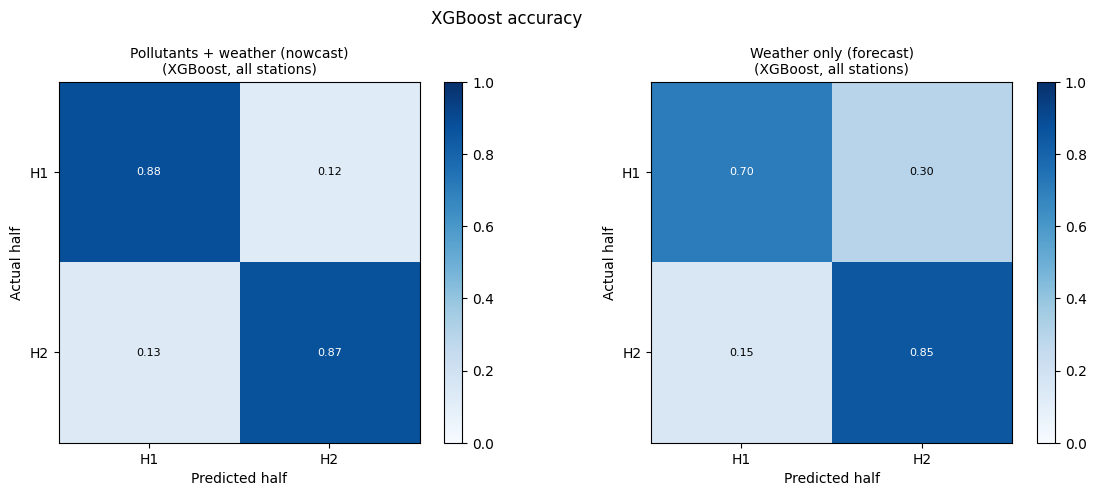

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, feature in zip(axes, FEATURE_SETS):
    key = (feature, "All stations")
    split = splits[key]
    model = fitted_models[key]["binary classification"]["XGBoost"]
    binary_label_encoder = fitted_models[key]["binary_label_encoder"]

    y_test_enc = binary_label_encoder.transform(split["y_test_binary"])
    preds = model.predict(split["X_test"])
    cm = confusion_matrix(y_test_enc, preds, normalize="true")

    im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(len(binary_label_encoder.classes_)))
    ax.set_xticklabels(binary_label_encoder.classes_)
    ax.set_yticks(range(len(binary_label_encoder.classes_)))
    ax.set_yticklabels(binary_label_encoder.classes_)
    ax.set_xlabel("Predicted half")
    ax.set_ylabel("Actual half")
    ax.set_title(f"{feature}\n(XGBoost, all stations)", fontsize=10)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, f"{cm[i, j]:.2f}", ha="center", va="center",
                     color="white" if cm[i, j] > 0.5 else "black", fontsize=8)
    plt.colorbar(im, ax=ax, fraction=0.046)

fig.suptitle("XGBoost accuracy")
plt.tight_layout()
plt.show()